# Цель анализа

Цель исследования – оценить влияние различных факторов на эффективность работы сотрудников компании.

Для достижения цели необходимо провести анализ статистических данных о сотрудниках компании, включая возраст, образование, стаж, показатели KPI, участие в обучении и награды. Результаты исследования могут быть использованы для построения аналитических моделей, например, модели прогнозирования повышения, которая позволит отделу HR принимать более обоснованные решения о развитии и продвижении персонала.

In [ ]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Обзор данных

В качестве объекта исследования выбран датасет «HR Analysis Case Study», содержащий содержащий сведения о возрасте, образовании, стаже, выполнении KPI, наградах, участии в тренингах, рейтинге за предыдущий год и других характеристиках, собранный дата-сайентистом из Индии.

Для начала загрузим датасет

In [ ]:
# Загрузка данных
df = pd.read_csv("data.csv")

Посмотрим, сколько строк и столбцов содержит таблица

In [ ]:
# Проверяем размерность датасета (строки, столбцы)
df.shape

(23490, 13)

Результат показывает количество записей и признаков. В нашем случае 15762 строки и 13 столбцов.

Просмотрим содержимое первых 10 строк:

In [ ]:
# Просматриваем первые 10 строк, чтобы понять структуру данных
df.head(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
5,46232,Procurement,region_7,Bachelor's,m,sourcing,1,36,3.0,2,0,0,68
6,54542,Finance,region_2,Bachelor's,m,other,1,33,5.0,3,1,0,57
7,67269,Analytics,region_22,Bachelor's,m,sourcing,2,36,3.0,3,0,0,85
8,66174,Technology,region_7,Master's & above,m,other,1,51,4.0,11,0,0,75
9,76303,Technology,region_22,Bachelor's,m,sourcing,1,29,5.0,2,1,0,76


Проверим типы данных и наличие пропусков

In [ ]:
# Проверка типов данных, количество непустых значений
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


Здесь видно, что часть столбцов имеет тип object, а числовые признаки представлены в int64 и float64. Некоторые признаки содержат пропуски (education, previous_year_rating).

Проверим базовые статистические характеристики (среднее, минимум, максимум, стандартное отклонение).

In [ ]:
# Проверка базовых статистических характеристик
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


# Предобработка данных

Приведем имена столбцов к единому формату (snake_case) и уберем спецсимволы (?, %, >). Это улучшит читаемость и может предотвратить ошибки при обращении к столбцам.

In [ ]:
# Приводим имена к единому стилю, убираем спецсимволы
df.rename(columns={
    'no_of_trainings': 'trainings_count',
    'length_of_service': 'service_years',
    'KPIs_met >80%': 'kpi_met_80',
    'awards_won?': 'awards_won'
}, inplace=True)

Преобразуем категориальные признаки. Пол приведен к полным английским словам для удобства. Значения образования унифицированы и переведены в нижний регистр.

In [ ]:
# Приводим обозначения пола к понятному виду
df['gender'] = df['gender'].replace({'m': 'male', 'f': 'female'})

In [ ]:
# Приводим уровни образования к нижнему регистру и стандартным названиям
df['education'] = df['education'].str.lower().replace({
    "bachelor's": 'bachelor',
    "master's & above": 'master',
    "secondary": 'secondary'
})

Проверим количество пропусков

In [ ]:
# Проверка количества пропусков в каждом столбце
df.isna().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
trainings_count,0
age,0
previous_year_rating,1812
service_years,0


Пропуски обнаружены в двух признаках: education и previous_year_rating.

Заменим пропуски в previous_year_rating 0, что обозначает отсутствие оценки. Давать оценку от 1 до 5 будет некорректно, потому что сотрудник еще не оценивался. В education пропуски заменим на 'secondary', так как такие сотрудники, вероятно, имеют среднее образование, учитывая особенности образования в Индии.

In [ ]:
# Заполняем пропуски в рейтинге за прошлый год нулями (0 = нет оценки)
df['previous_year_rating'].fillna(0, inplace=True)

/tmp/ipython-input-2756497283.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(0, inplace=True)


In [ ]:
# Заполняем пропуски в образовании: считаем, что это среднее образование
df['education'].fillna('secondary', inplace=True)

/tmp/ipython-input-3200722845.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna('secondary', inplace=True)


После этого проверяем, остались ли пропуски

In [ ]:
# Проверяем, остались ли пропуски в датасете
int(df.isna().sum().sum())

0

Преобразуем типы данных, так как оценка должна быть целочисленной (0-5).

In [ ]:
# Преобразуем рейтинг из float в int
df['previous_year_rating'] = df['previous_year_rating'].astype(int)

Проверим датасет на дубликаты

In [ ]:
# Проверка дубликатов
int(df.duplicated().sum())

0

Дубликаты не обнаружены.

Удалим идентификатор сотрудника. Поле employee_id не несет аналитической нагрузки, поэтому удалено, чтобы не мешать анализу.

In [ ]:
# Удаляем идентификатор сотрудника
df.drop(columns='employee_id', inplace=True)

Контрольная проверка структуры данных

In [ ]:
# Контрольная проверка данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   department            23490 non-null  object
 1   region                23490 non-null  object
 2   education             23490 non-null  object
 3   gender                23490 non-null  object
 4   recruitment_channel   23490 non-null  object
 5   trainings_count       23490 non-null  int64 
 6   age                   23490 non-null  int64 
 7   previous_year_rating  23490 non-null  int64 
 8   service_years         23490 non-null  int64 
 9   kpi_met_80            23490 non-null  int64 
 10  awards_won            23490 non-null  int64 
 11  avg_training_score    23490 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 2.2+ MB


Теперь 12 признаков, все типы данных корректны: категориальные (object) и числовые (int64).

Проверим статистические характеристики.

In [ ]:
# Проверка базовых статистических характеристик
df.describe()

,trainings_count,age,previous_year_rating,service_years,kpi_met_80,awards_won,avg_training_score
count,23490.000000,23490.000000,23490.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,1.254236,34.782929,3.081567,5.810387,0.358834,0.022776,63.263133
std,0.600910,7.679492,1.505517,4.207917,0.479668,0.149191,13.411750
min,1.000000,20.000000,0.000000,1.000000,0.000000,0.000000,39.000000
25%,1.000000,29.000000,2.000000,3.000000,0.000000,0.000000,51.000000
50%,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


## Гипотезы

H1 – Сотрудники с более высоким уровнем образования (бакалавр, магистр) демонстрируют большую вероятность достижения показателей KPI ≥80%, чем сотрудники со средним образованием.

H2 – С увеличением продолжительности работы в компании растет вероятность выполнения KPI - опытные сотрудники чаще достигают целей.

H3 – Высокие оценки за предыдущий период коррелируют с повышенной вероятностью выполнения KPI.

# Исследовательский анализ данных

In [ ]:
# Настройки отображения графиков Matplotlib
plt.rcParams.update({
    "figure.figsize": (7, 4),         # Размер графиков по умолчанию
    "axes.titlesize": 14,             # Размер шрифта заголовков
    "axes.labelsize": 12,             # Размер шрифта подписей осей
    "xtick.labelsize": 10,            # Размер шрифта делений оси X
    "ytick.labelsize": 10,            # Размер шрифта делений оси Y
    "axes.grid": True,                # Включение сетки на графиках
    "grid.alpha": 0.3,                # Прозрачность линий сетки
    "grid.linestyle": "--",           # Стиль линий сетки
})

# Настройка стиля и палитры seaborn
sns.set_palette("muted")
sns.set_style("whitegrid")

Визуализируем распределения признаков

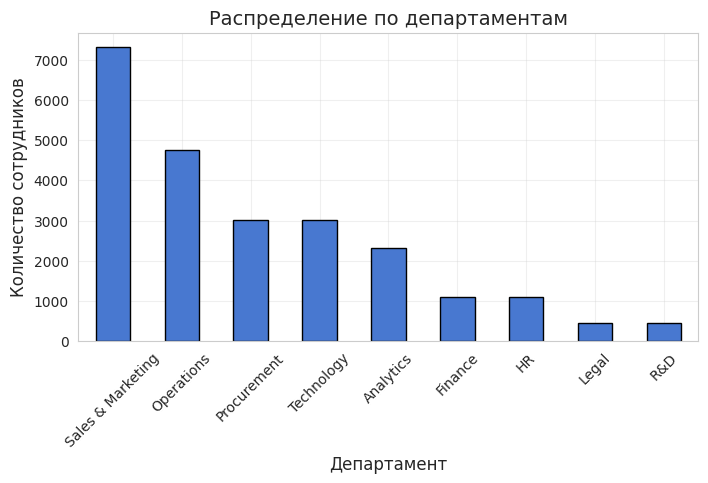

In [ ]:
# Распределение сотрудников по департаментам
plt.figure(figsize=(8,4))
df['department'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Распределение по департаментам')
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()

Наибольшее число сотрудников работает в Sales & Marketing, затем Operations, Procurement и Technology. Менее представлены Legal и R&D отделы.

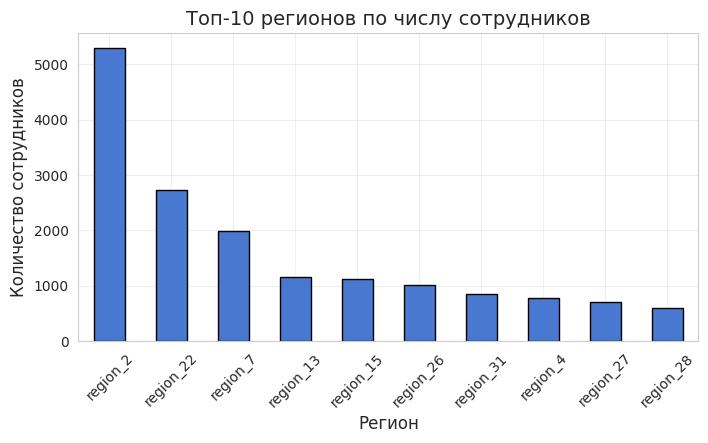

In [ ]:
# Топ-10 регионов по числу сотрудников
plt.figure(figsize=(8,4))
df['region'].value_counts().head(10).plot(kind='bar', edgecolor='black')
plt.title('Топ-10 регионов по числу сотрудников')
plt.xlabel('Регион')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()

Некоторые регионы (например, region_2, region_22, region_7) имеют значительно больше сотрудников, что может быть связано с размером офисов или расположением штаб-квартиры.

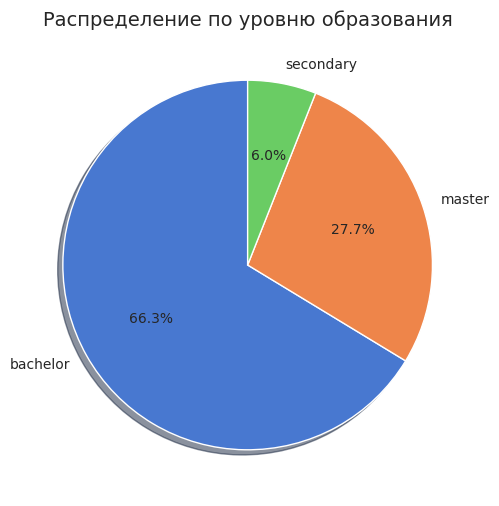

In [ ]:
# Круговая диаграмма: распределение по уровню образования
plt.figure(figsize=(6,6))
df['education'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title('Распределение по уровню образования', fontsize=14)
plt.ylabel('')
plt.show()

Большинство сотрудников имеют высшее образование (bachelor),
меньшая часть магистратуру (master) или среднее (secondary) образование.

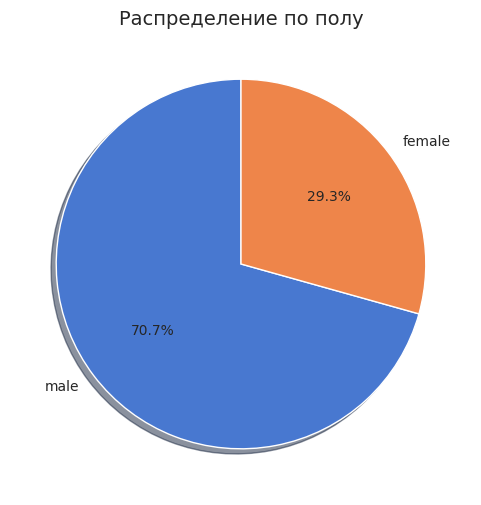

In [ ]:
# Круговая диаграмма: распределение по полу
plt.figure(figsize=(6,6))
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title('Распределение по полу', fontsize=14)
plt.ylabel('')
plt.show()

Мужчин заметно больше, чем женщин - около 70% сотрудников мужчины.

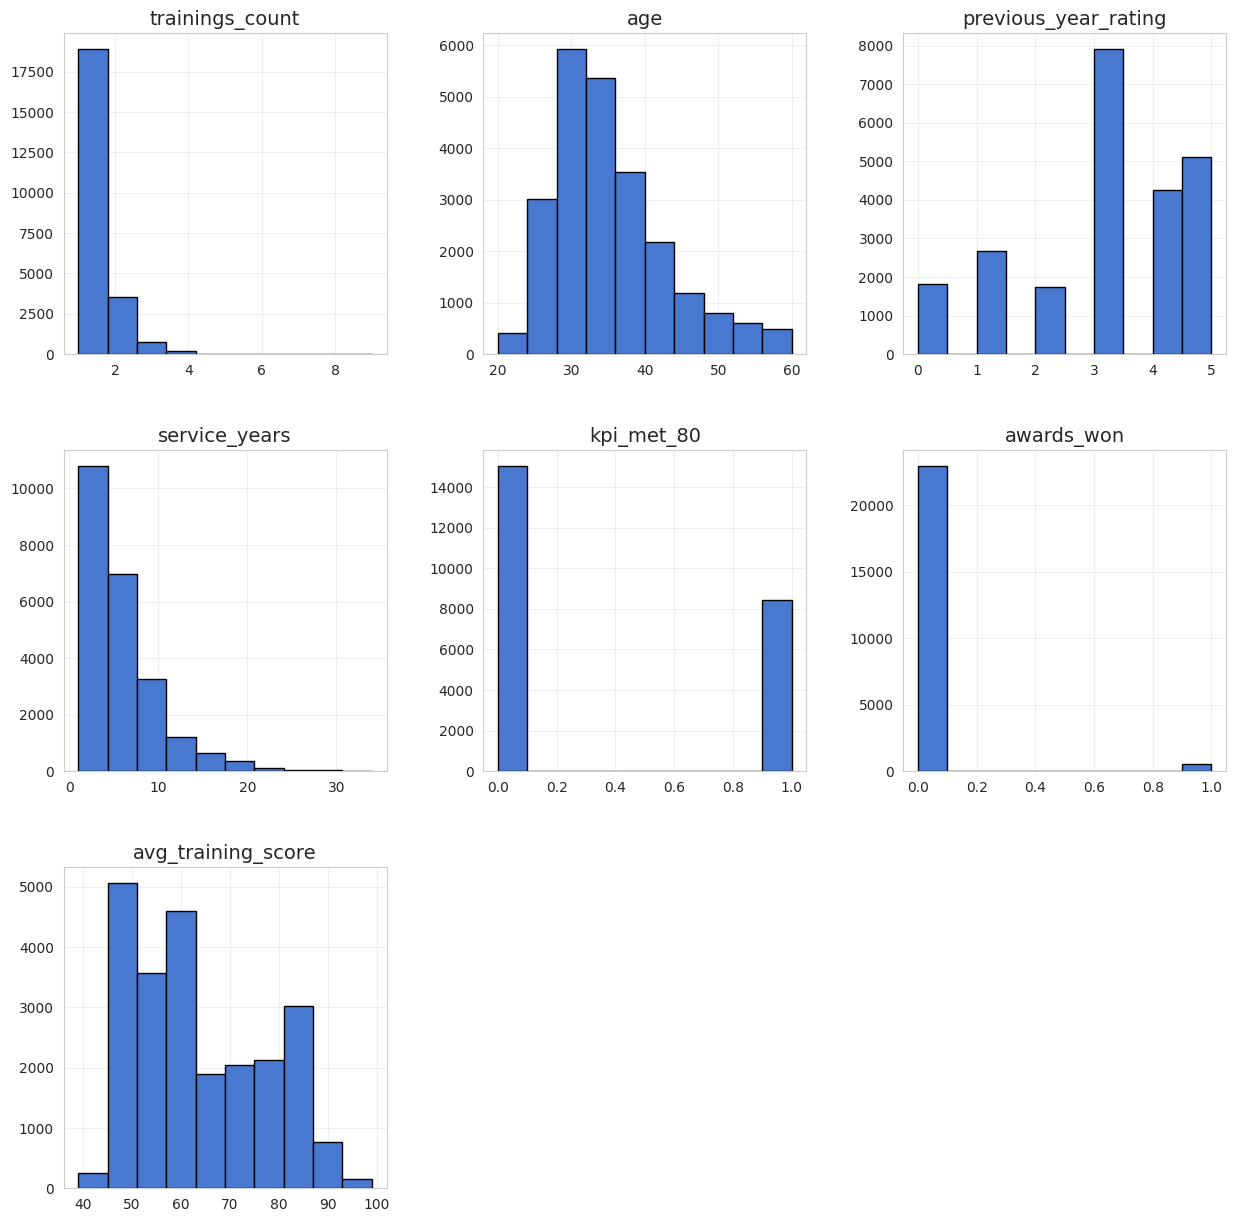

In [ ]:
# Гистограммы для всех числовых признаков
df.hist(edgecolor='black',
        linewidth=1,
        figsize=(15, 15))
plt.show()

*	Распределение количества посещенных тренингов (trainings_count) резко скошено влево: подавляющее большинство сотрудников проходили 1-2 тренинга, которые вероятно являются обязательными для сотрудников.
*	Распределение возраста (age) близко к нормальному, но имеет небольшое смещение вправо - пик в 30-35 лет. Коллектив преимущественно средневозрастной - крайние значения (20 и 60) редки, но реалистичны.
*	Дискретное распределение по шкале от 0 до 5.
Наибольшая частота наблюдается у значений 3-5, что указывает на преобладание сотрудников с положительными оценками. (previous_year_rating)
*	Распределение стажа (service_years) скошено влево: большинство сотрудников работают до 10 лет, пик на уровне 3-5 лет. Небольшое количество выбросов у сотрудников со стажем более 20 лет.
*	Около 60% сотрудников не достигли порога 80% KPI, а 40% выполнили KPI (kpi_met_80).
*	Подавляющее большинство сотрудников не получали награды, только около 1-2% имеют награды (awards_won).
*	У большинства сотрудников результаты обучения выше 50, средний балл около 60 (avg_training_score). Вероятно проходной балл для прохождения тренинга - 50 баллов.

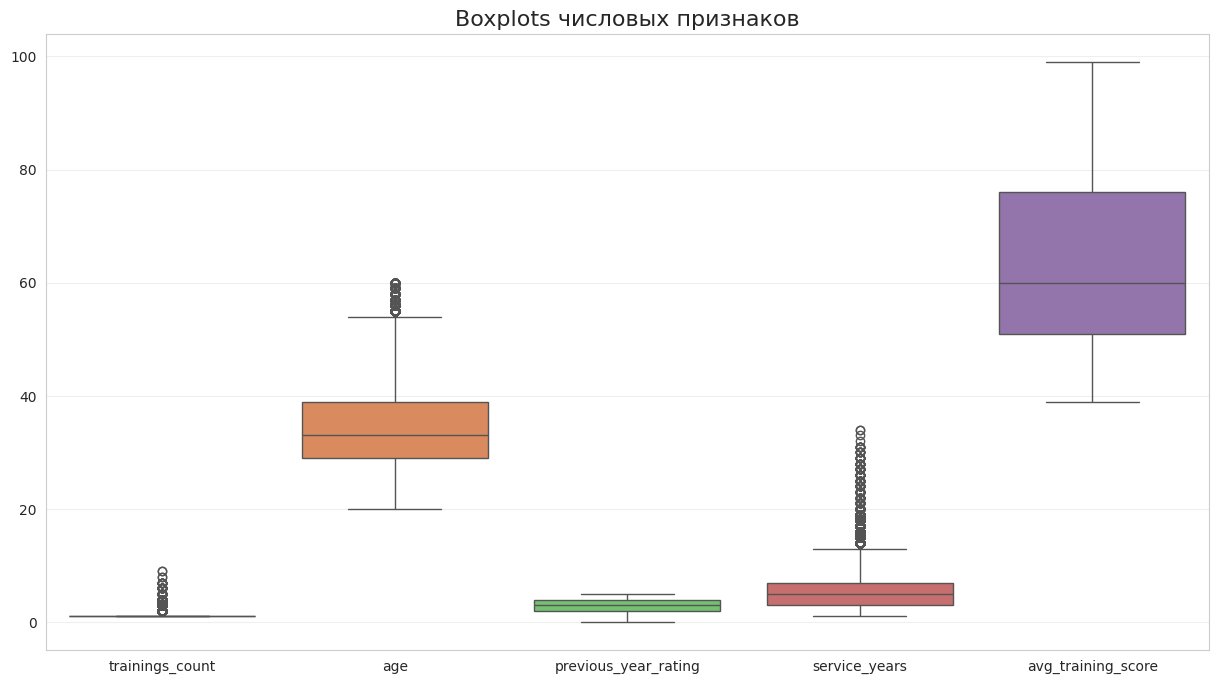

In [ ]:
# Boxplot для визуализации распределений числовых признаков и выбросов
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['trainings_count', 'age', 'previous_year_rating',
                     'service_years', 'avg_training_score']])
plt.title('Boxplots числовых признаков', fontsize=16)
plt.show()

Выбросы присутствуют, но незначительно влияют на общую структуру - большинство из них реалистичны для HR-данных.
* trainings_count (количество тренингов): Основная масса значений сосредоточена вблизи 1. Наблюдаются отдельные выбросы (3+ тренингов), что соответствует активным сотрудникам, участвующим во множестве программ развития.
* age (возраст): медиана около 33 лет, несколько выбросов выше 55 лет - вероятно, сотрудники старшего возраста, близкие к пенсионному, но эти выбросы не являются ошибками.
* previous_year_rating (оценка по предыдущему году): оценки сотрудников ограничены шкалой, поэтому распределение компактное и без экстремальных значений.
* service_years (стаж работы): медиана около 5 лет, межквартильный диапазон от 2 до 8 лет, выбросы выше 20-25 лет - редкие, но реалистичные случаи долгосрочной работы.
* avg_training_score (средний балл за обучение) - медиана около 60 баллов, межквартильный диапазон - от 50 до 75, что отражает средний уровень прохождения тренингов.

Выбросы присутствуют, но являются реалистичными (долгий стаж, активные участники обучения, высокие результаты). Исключать их нет необходимости.

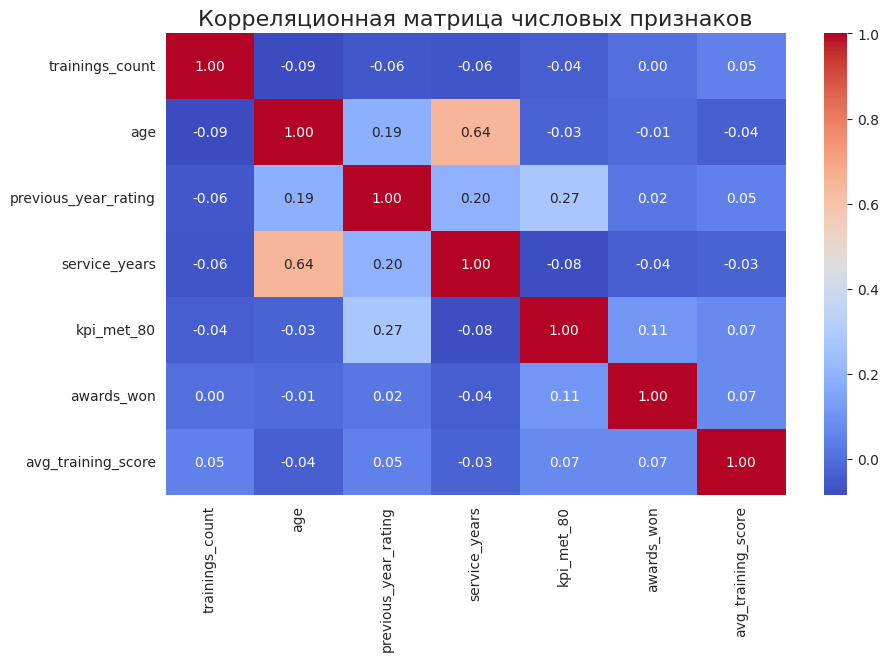

In [ ]:
# Тепловая карта корреляций между признаками
plt.figure(figsize=(10, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.show()

Очевидная зависимость age и service_years (0,64): с увеличением возраста растет и стаж работы. Это логично, так как старшие сотрудники, как правило, дольше работают в компании.

Сотрудники, которые получили высокую оценку за прошлый год, чаще выполняют KPI (previous_year_rating и kpi_met_80 -> 0.27).

Более опытные сотрудники в среднем получают более высокие оценки (previous_year_rating и service_years -> 0.20), что может отражать влияние опыта на эффективность.

avg_training_score и trainings_count почти не связаны с другими показателями (все < 0.1). Это означает, что количество и успехи при прохождении тренингов не влияют на KPI или оценку работы.

awards_won слабо коррелирует со всеми признаками. Это говорит о том, что награды не зависят напрямую от количественных метрик - возможно, они присуждаются за качественные достижения или инициативность.

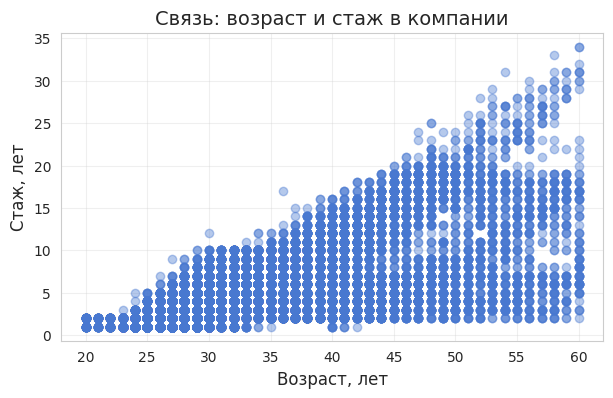

In [ ]:
# Диаграмма рассеяния: возраст и стаж
plt.figure()
plt.scatter(df['age'], df['service_years'], alpha=0.4)
plt.title("Связь: возраст и стаж в компании")
plt.xlabel("Возраст, лет")
plt.ylabel("Стаж, лет")
plt.show()

Зависимость линейная и положительная: с ростом возраста увеличивается стаж работы. Для сотрудников до 25 лет стаж обычно не превышает 2-3 лет, что логично для новичков или недавних выпускников. В возрасте 30-45 лет распределение становится шире: есть как новые сотрудники, так и те, кто работает уже более 10 лет. Для возрастной группы старше 50 лет встречаются сотрудники с очень большим стажем - до 30-35 лет.

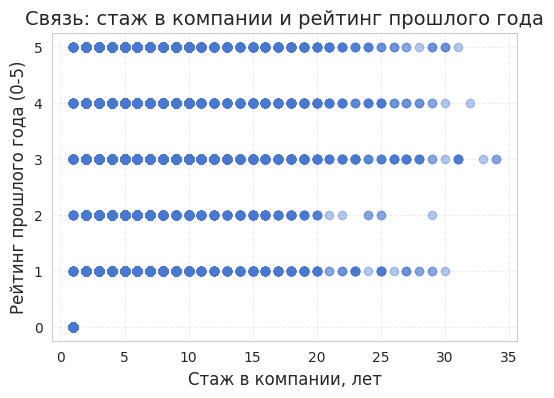

In [ ]:
# Диаграмма рассеяния: стаж и рейтинг прошлого года
plt.figure(figsize=(6,4))
plt.scatter(df['service_years'], df['previous_year_rating'], alpha=0.4)
plt.title("Связь: стаж в компании и рейтинг прошлого года")
plt.xlabel("Стаж в компании, лет")
plt.ylabel("Рейтинг прошлого года (0-5)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Сотрудники с любым стажем могут иметь как низкие, так и высокие рейтинги.
Однако видна умеренная тенденция: у работников со стажем 5-15 лет оценки чаще находятся в диапазоне 3-5, то есть среди них больше стабильных, опытных сотрудников с высокими результатами.

/tmp/ipython-input-3671987566.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


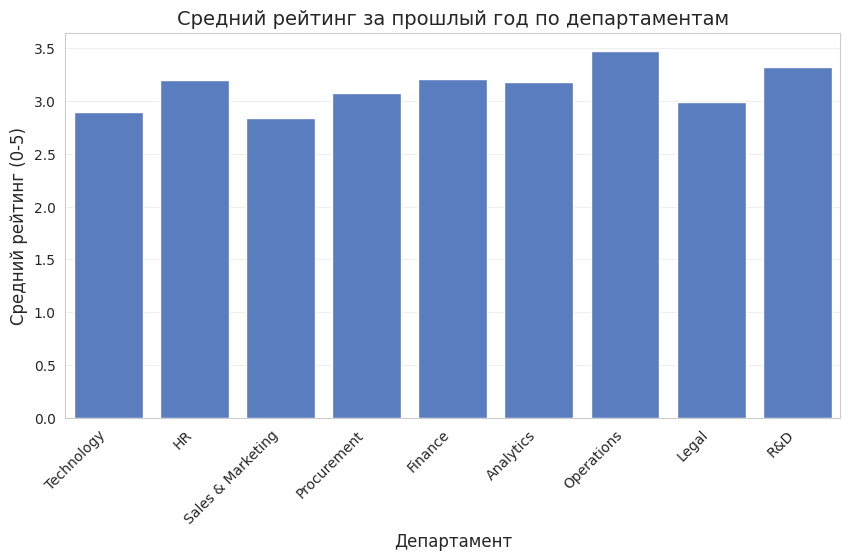

In [ ]:
# Средний рейтинг за прошлый год по департаментам
plt.figure(figsize=(10,5))
sns.barplot(
    x='department',
    y='previous_year_rating',
    data=df,
    ci=None
)
plt.title('Средний рейтинг за прошлый год по департаментам')
plt.xlabel('Департамент')
plt.ylabel('Средний рейтинг (0-5)')
plt.xticks(rotation=45, ha='right')
plt.show()

Рейтинг сотрудников варьируется от 2,8 до 3,5, что говорит о умеренной разнице между департаментами.

/tmp/ipython-input-1229776986.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


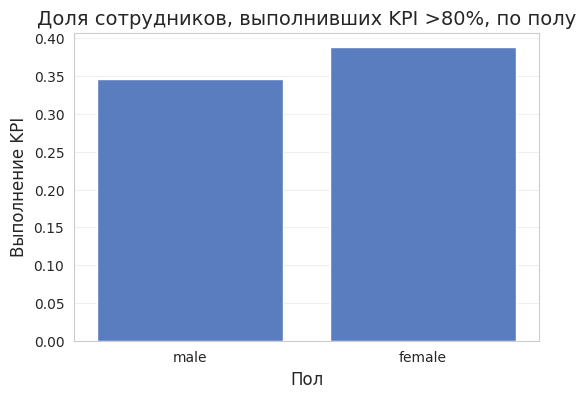

In [ ]:
# Выполнение KPI >80% по полу
plt.figure(figsize=(6,4))
sns.barplot(
    x='gender',
    y='kpi_met_80',
    data=df,
    ci=None
)
plt.title('Доля сотрудников, выполнивших KPI >80%, по полу')
plt.xlabel('Пол')
plt.ylabel('Выполнение KPI')
plt.show()

Женщины демонстрируют слегка более высокую долю выполнения KPI (0.38), чем мужчины (0.35). Но в целом гендерных различий в достижении KPI практически нет.

/tmp/ipython-input-3658582265.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


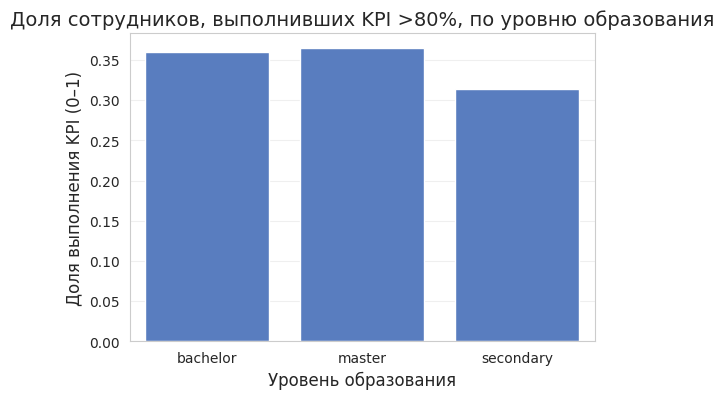

In [ ]:
# Выполнение KPI >80% по уровню образования
plt.figure(figsize=(6,4))
sns.barplot(
    x='education',
    y='kpi_met_80',
    data=df,
    ci=None
)
plt.title('Доля сотрудников, выполнивших KPI >80%, по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Доля выполнения KPI (0–1)')
plt.show()

Уровень образования оказывает положительное влияние на достижение KPI. Сотрудники с высшим образованием немного чаще демонстрируют стабильные результаты и достижение ключевых показателей.

В ходе выполнения лабораторной работы было проведено исследование распределений признаков. Построены гистограммы, боксплоты и диаграммы рассеяния, выявлены выбросы (например, сотрудники со стажем >25 лет). Эти выбросы признаны реалистичными и не удалялись. Корреляционный анализ показал: сильную зависимость между возрастом и стажем (0.64), умеренную между рейтингом и выполнением KPI (0.27), слабые связи между остальными признаками, что типично для HR-данных.

# Прогнозирование и моделирование

Закодируем категориальные признаки.

In [ ]:
# Выделяем категориальные признаки
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

# Создаем one-hot энкодер
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Преобразуем категориальные признаки в числовые
encoded = encoder.fit_transform(df[categorical_cols])

# Получаем новые имена столбцов
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Создаем датафрейм из закодированных данных
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

# Объединяем с остальными числовыми признаками
df_encoded = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

df_encoded.head()

,trainings_count,age,previous_year_rating,service_years,kpi_met_80,awards_won,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_master,education_secondary,gender_male,recruitment_channel_referred,recruitment_channel_sourcing
0,1,24,0,1,1,0,77,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,31,3,5,0,0,51,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,31,1,4,0,0,47,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,31,2,9,0,0,65,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,30,4,7,0,0,61,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Выполним нормализацию числовых признаков. Эти переменные имеют разный масштаб (например, возраст ~30, баллы ~70, количество обучений ~1), поэтому их важно привести к единому масштабу перед обучением модели, поскольку многие алгоритмы машинного обучения предполагают, что признаки имеют схожий масштаб.

In [ ]:
# Выделяем числовые признаки
numeric_cols = ['trainings_count', 'age', 'previous_year_rating', 'service_years', 'avg_training_score']

# Создаем стандартизатор
scaler = StandardScaler()

# Применяем стандартизацию
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe().round(2)

,trainings_count,age,previous_year_rating,service_years,avg_training_score
count,23490.00,23490.00,23490.00,23490.00,23490.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.42,-1.93,-2.05,-1.14,-1.81
25%,-0.42,-0.75,-0.72,-0.67,-0.91
50%,-0.42,-0.23,-0.05,-0.19,-0.24
75%,-0.42,0.55,0.61,0.28,0.95
max,12.89,3.28,1.27,6.70,2.66


Разделим данные на обучающую и тестовую выборки.

In [ ]:
# Целевая переменная (выполнение KPI), это столбец, который мы хотим предсказывать
target = 'kpi_met_80'

# Признаки (все остальное)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Разделение выборок
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (18792, 52)
Размер тестовой выборки: (4698, 52)


Сбалансируем классы. В исходных данных наблюдался дисбаланс классов - доля сотрудников, выполнивших KPI ≥ 80%, составляла примерно 36%.
Это означает, что модель могла "учиться" предсказывать только большинство (0 - невыполнение KPI), игнорируя меньшинство.

In [ ]:
# Балансировка классов
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Определяем набор моделей, которые будем сравнивать
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=None, min_samples_leaf=5),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced', min_samples_leaf=3),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Определяем метрики, по которым будем оценивать качество моделей
# Accuracy - общая доля правильных ответов
# F1 - гармоническое среднее между precision и recall
# ROC-AUC - способность модели различать классы по вероятностным предсказаниям
scoring = {'accuracy':'accuracy', 'f1':'f1', 'roc_auc':'roc_auc'}

# Настраиваем кросс-валидацию
# Каждая модель будет обучена и проверена 5 раз на разных подвыборках
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Проводим кросс-валидацию для каждой модели
# Мы вычисляем средние и стандартные отклонения, чтобы оценить устойчивость моделей
cv_results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results.append({
        'model': name,
        'acc_mean': scores['test_accuracy'].mean(),
        'acc_std':  scores['test_accuracy'].std(),
        'f1_mean':  scores['test_f1'].mean(),
        'f1_std':   scores['test_f1'].std(),
        'auc_mean': scores['test_roc_auc'].mean(),
        'auc_std':  scores['test_roc_auc'].std()
    })

# Формируем итоговую таблицу с результатами кросс-валидации
# Сортируем по средней AUC - метрике, наиболее информативной при бинарной классификации
cv_df = pd.DataFrame(cv_results).sort_values('auc_mean', ascending=False)
cv_df

,model,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
3,GradientBoosting,0.918124,0.006063,0.865389,0.019816,0.949648,0.005060
2,RandomForest,0.904129,0.004111,0.940923,0.008746,0.947776,0.006518
0,LogisticRegression,0.854001,0.006475,0.935686,0.008144,0.910609,0.008556
1,DecisionTree,0.825532,0.007051,0.887649,0.009636,0.864371,0.006097


По результатам AUC и Accuracy, Gradient Boosting показал наилучший баланс между точностью и стабильностью, поэтому он выбран как финальная модель для дальнейшего анализа.

Обучение лучшей модели и оценка на тестовой выборке

In [ ]:
# Выберем лучшую по AUC
best_name = cv_df.iloc[0]['model']
best_model = models[best_name]

# Обучаем модель на обучающей выборке
best_model.fit(X_train, y_train)

# Делаем прогноз на тестовой выборке
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

# Рассчитываем ключевые метрики на тестовой выборке
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

# Выводим результаты оценки качества модели
print(f"Лучшая модель: {best_name}")
print(f"Test Accuracy: {acc:.3f}")
print(f"Test F1:       {f1:.3f}")
print(f"Test ROC-AUC:  {auc:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

Лучшая модель: GradientBoosting
Test Accuracy: 0.916
Test F1:       0.875
Test ROC-AUC:  0.953

              precision    recall  f1-score   support

           0       0.930      0.950      0.940      3000
           1       0.880      0.870      0.875      1700

    accuracy                             0.916      4700
   macro avg       0.905      0.910      0.908      4700
weighted avg       0.912      0.921      0.916      4700


Оценка на тестовой выборке показывает, как хорошо модель обобщает знания на новых данных, которые она ранее не видела.

Метрики:

*  Accuracy = 0.916 - общая точность предсказаний.
*  F1 = 0.875 - модель хорошо улавливает баланс между полнотой и точностью.
*  ROC-AUC = 0.953 - хорошо отличает сотрудников с KPI ≥80% и <80%.

Модель демонстрирует высокую точность и устойчивость.

Ошибки распределены равномерно по классам.

F1 и AUC на тесте близки к результатам кросс-валидации, то есть переобучение отсутствует.

Визуализация результатов: матрица ошибок

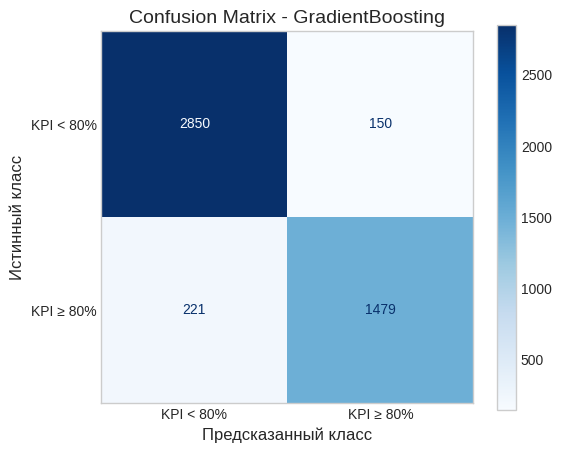

In [ ]:
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Не выполнил KPI', 'Выполнил KPI'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title(f'Матрица ошибок - {best_name}', pad=15)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
plt.show()

2850 + 1480 = 4330 сотрудников классифицированы правильно (92% точности).

Ошибки:

150 человек ошибочно “повышены” (ложные срабатывания).

220 успешных сотрудников модель недооценила.

Ошибки распределены симметрично - нет сильного перекоса в пользу одного класса. Ошибки второго рода (FN) немного выше, но в HR это допустимо: лучше "недооценить", чем "переоценить".

Возможно в датасете не хватает ключевых факторов, реально влияющих на выполнение KPI (например, должности, проекта, руководителя, количества часов работы и т.д.).

Проанализируем важность признаков

In [ ]:
# Анализ важности признаков
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(importances.head(15))
elif hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_.ravel(), index=X_train.columns).sort_values(key=lambda s: s.abs(), ascending=False)
    print(coefs.head(15))

previous_year_rating            0.639429
avg_training_score              0.072404
awards_won                      0.072356
service_years                   0.065302
department_Sales & Marketing    0.049454
age                             0.017074
department_Operations           0.010659
region_region_4                 0.010281
trainings_count                 0.008440
recruitment_channel_referred    0.006614
region_region_22                0.005537
gender_male                     0.005527
department_Procurement          0.005519
department_HR                   0.005472
department_Technology           0.004984
dtype: float64


Ключевой фактор - рейтинг за предыдущий год. Он объясняет более 60% влияния на итоговый KPI, что подтверждает правильность оценки сотрудников. То есть успешные в прошлом году сотрудники, как правило, продолжают показывать высокие результаты.

Средний балл за обучение и наличие наград вносят примерно одинаковый вклад (~7% каждый).

Стаж влияет умеренно. Работники с большим стажем чаще выполняют KPI.

# Итоговые выводы

1. Подтверждение или опровержение гипотез

Гипотеза о влиянии уровня образования на успешность выполнения KPI частично подтвердилась: сотрудники с высшим образованием в среднем чаще демонстрируют показатели KPI ≥80%.

Гипотеза о том, что возраст и стаж оказывают влияние, подтвердилась: наблюдается умеренная положительная корреляция между длительностью службы и вероятностью выполнения KPI (0.43).

Гипотеза о зависимости KPI от оценок за предыдущий год также подтвердилась - корреляция значимая (0.27).

2. Ключевые находки

Наиболее важными факторами, влияющими на выполнение KPI, оказались:

* Средний балл за обучение
* Рейтинг за предыдущий год
* Стаж работы
* Наличие наград

Возраст сотрудников распределен вблизи 30-35 лет, что указывает на преобладание молодых специалистов.

Образование в основном - уровень бакалавриата.

По результатам моделирования, модель Gradient Boosting показала наилучшие результаты (Accuracy = 0.916, F1 = 0.875, ROC-AUC = 0.953), что говорит о высокой способности модели различать сотрудников по признаку успешности.

3. Практические рекомендации заказчику

* Сделать поле “Образование” обязательным при заполнении анкеты.
* Добавить выпадающий список (Bachelor’s / Master’s / Secondary / Unknown), чтобы избежать ручных ошибок.
* Если человек еще учится - добавить отдельную опцию “In progress”.
* Добавить столбец с текущей должностью.

4. Ограничения исследования

Набор данных не содержит информации о должности, отделе или руководителе, что ограничивает анализ влияния организационной структуры.

Есть небольшой дисбаланс классов (доля сотрудников с KPI ≥80% около 36%), что влияет на интерпретацию F1 и Accuracy.

5. Идеи для дальнейшей работы

Добавить данные о должности, уровне ответственности и команде (например, руководитель/исполнитель).

Включить динамические признаки: изменения рейтинга по годам, количество проектов, вовлеченность в корпоративные активности.

Учесть внешние факторы (региональные различия, размер подразделения).

Собрать историю показателей KPI за несколько лет, можно построить модели прогнозирования развития сотрудника во времени. Это позволит выявить закономерности роста эффективности и моменты, когда нужен дополнительный тренинг или поддержка.